## AudiSense: Multimodal late fusion for suicidal ideation detection on TikTok



##  Imports and Setup

In [ ]:
#  standard library
import re


#  numerical / data
import numpy as np
import pandas as pd

# sklearn
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    matthews_corrcoef, precision_recall_curve,
    roc_curve, auc, confusion_matrix
)


import matplotlib.pyplot as plt
import seaborn as sns

# global seed
SEED = 42
np.random.seed(SEED)
print("Libraries loaded.")


Libraries loaded.


##  Evaluation Helpers


In [ ]:
def calibrate_threshold(y_true, y_prob):
    """F1-optimal threshold on a held-out split (never use y_test here)."""
    p, r, thr = precision_recall_curve(y_true, y_prob)
    f1 = 2 * p * r / (p + r + 1e-10)
    return float(thr[np.argmax(f1[:-1])])


def evaluate(name, y_true, y_prob, threshold, bootstrap_n=1000, verbose=True):
    """
    Full evaluation with bootstrap 95% CIs.
    Primary metric: AUPRC (more informative than AUC for imbalanced datasets).
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    auprc = average_precision_score(y_true, y_prob)
    roc   = roc_auc_score(y_true, y_prob)
    f1    = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    prec  = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec   = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    mcc   = matthews_corrcoef(y_true, y_pred)

    rng  = np.random.default_rng(SEED)
    boot = {k: [] for k in ("auprc", "auc", "f1", "mcc")}
    n    = len(y_true)
    for _ in range(bootstrap_n):
        idx = rng.integers(0, n, size=n)
        yt, yp = y_true[idx], y_prob[idx]
        yb = (yp >= threshold).astype(int)
        if len(np.unique(yt)) < 2:
            continue
        boot["auprc"].append(average_precision_score(yt, yp))
        boot["auc"].append(roc_auc_score(yt, yp))
        boot["f1"].append(f1_score(yt, yb, pos_label=1, zero_division=0))
        boot["mcc"].append(matthews_corrcoef(yt, yb))

    def ci(arr):
        arr = np.array(arr)
        return np.percentile(arr, 2.5), np.percentile(arr, 97.5)

    results = dict(
        name=name, auprc=auprc, roc_auc=roc,
        f1=f1, prec=prec, rec=rec, mcc=mcc,
        threshold=threshold,
        ci_auprc=ci(boot["auprc"]),
        ci_auc=ci(boot["auc"]),
        ci_f1=ci(boot["f1"]),
        ci_mcc=ci(boot["mcc"]),
    )

    if verbose:
        print(f"\n{'='*55}")
        print(f"  {name}")
        print(f"{'='*55}")
        print(f"  AUPRC (primary) : {auprc:.4f}  95%CI [{ci(boot['auprc'])[0]:.3f}, {ci(boot['auprc'])[1]:.3f}]")
        print(f"  ROC-AUC         : {roc:.4f}  95%CI [{ci(boot['auc'])[0]:.3f}, {ci(boot['auc'])[1]:.3f}]")
        print(f"  F1 (pos)        : {f1:.4f}  95%CI [{ci(boot['f1'])[0]:.3f}, {ci(boot['f1'])[1]:.3f}]")
        print(f"  Precision (pos) : {prec:.4f}")
        print(f"  Recall (pos)    : {rec:.4f}")
        print(f"  MCC             : {mcc:.4f}  95%CI [{ci(boot['mcc'])[0]:.3f}, {ci(boot['mcc'])[1]:.3f}]")
        print(f"  Threshold (val) : {threshold:.4f}")

    return results


## Data Loading and Text Preprocessing

In [ ]:
def clean_text(t):
    if not isinstance(t, str):
        return ""
    t = re.sub(r"http\S+|www\S+", "", str(t).lower())
    # keep hashtag markers explicitly — algospeak lives in hashtags
    t = re.sub(r"[^\w\s#]", " ", t)
    return re.sub(r"\s+", " ", t).strip()


df_raw = pd.read_csv("data_complet.csv", sep=None, engine="python", encoding="latin-1")
df_raw.columns = df_raw.columns.str.strip()

TEXT_COLS = ["video_title", "video_hashtags", "Comment", "Translation"]
for c in TEXT_COLS:
    df_raw[c] = df_raw[c].fillna("").apply(clean_text)

RAW_ENG = ["Comment_count", "Like_count", "View_count", "Share_count", "Bookmark_count"]
for c in RAW_ENG:
    df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

df_raw["True_Label"] = pd.to_numeric(df_raw["True_Label"], errors="coerce").fillna(0).astype(int)

# Aggregate to video level — label = max across comment rows (any positive → video positive)
df = df_raw.groupby("video_id").agg(
    video_title   = ("video_title",   "first"),
    video_hashtags= ("video_hashtags","first"),
    Translation   = ("Translation",   "first"),       # Whisper English transcript
    Comment       = ("Comment",       lambda x: " [SEP] ".join(x)),
    Like_count    = ("Like_count",    "first"),
    View_count    = ("View_count",    "first"),
    Share_count   = ("Share_count",   "first"),
    Comment_count = ("Comment_count", "first"),
    Bookmark_count= ("Bookmark_count","first"),
    True_Label    = ("True_Label",    "max"),
).reset_index()

# Full text input: title + hashtags | transcript | audience comments
df["text_input"] = (
    df["video_title"] + " " + df["video_hashtags"] +
    " [SEP] " + df["Translation"] +
    " [SEP] " + df["Comment"]
)

# Text input WITHOUT transcript
df["text_input_notranscript"] = (
    df["video_title"] + " " + df["video_hashtags"] +
    " [SEP] " + df["Comment"]
)

print(f"Dataset: {len(df)} videos | "
      f"Positive: {df['True_Label'].sum()} ({100*df['True_Label'].mean():.1f}%)")


Dataset: 136 videos | Positive: 42 (30.9%)


## Stratified division Train / Val / Test Split

Split is done at video level to prevent comment-level leakage across partitions.
Ratio: 70 % train, 15 % val, 15 % test.


In [ ]:
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
tr_idx, tmp_idx = next(sss1.split(df.index, df["True_Label"]))

train_df = df.iloc[tr_idx].copy().reset_index(drop=True)
tmp_df   = df.iloc[tmp_idx].copy().reset_index(drop=True)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(sss2.split(tmp_df.index, tmp_df["True_Label"]))

val_df  = tmp_df.iloc[val_idx].copy().reset_index(drop=True)
test_df = tmp_df.iloc[test_idx].copy().reset_index(drop=True)

y_train = train_df["True_Label"].values
y_val   = val_df["True_Label"].values
y_test  = test_df["True_Label"].values

for split, name in [(train_df,"Train"),(val_df,"Val"),(test_df,"Test")]:
    lbl = split["True_Label"]
    print(f"{name:6s}: {len(split):3d} videos | "
          f"pos={lbl.sum()} ({100*lbl.mean():.1f}%)")

print(f"\nNote: test set has {len(test_df)} videos ({y_test.sum()} positive). "
      "Bootstrap CIs will be wide at this sample size.")


Train :  95 videos | pos=29 (30.5%)
Val   :  20 videos | pos=6 (30.0%)
Test  :  21 videos | pos=7 (33.3%)

Note: test set has 21 videos (7 positive). Bootstrap CIs will be wide at this sample size.


## Engagement Feature Engineering




In [ ]:
EPS = 1e-6

def engineer_features(df_in):
    d = df_in.copy()
    for c in RAW_ENG:
        d[c] = d[c].fillna(0)

    # ratio features
    d["like_per_view"]     = d["Like_count"]    / (d["View_count"] + EPS)
    d["comment_per_view"]  = d["Comment_count"] / (d["View_count"] + EPS)
    d["share_per_view"]    = d["Share_count"]   / (d["View_count"] + EPS)
    d["bookmark_per_view"] = d["Bookmark_count"]/ (d["View_count"] + EPS)
    d["comment_per_like"]  = d["Comment_count"] / (d["Like_count"] + EPS)
    d["bookmark_per_share"]= d["Bookmark_count"]/ (d["Share_count"]+ EPS)

    # aggregate engagement
    eng_ch = ["Like_count","Comment_count","Share_count","Bookmark_count"]
    d["eng_total"] = d[eng_ch].sum(axis=1)
    d["eng_rate"]  = d["eng_total"] / (d["View_count"] + EPS)

    # Herfindahl–Hirschman concentration index
    tot = d[eng_ch].sum(axis=1) + EPS
    d["eng_hhi"] = (d[eng_ch].div(tot, axis=0) ** 2).sum(axis=1)

    # log1p compression of all numeric features
    all_num = RAW_ENG + [
        "like_per_view","comment_per_view","share_per_view","bookmark_per_view",
        "comment_per_like","bookmark_per_share","eng_rate","eng_total"
    ]
    for c in all_num:
        d[c] = np.log1p(d[c])

    return d

FEAT_COLS = RAW_ENG + [
    "like_per_view","comment_per_view","share_per_view","bookmark_per_view",
    "comment_per_like","bookmark_per_share","eng_rate","eng_total","eng_hhi"
]

train_feat = engineer_features(train_df)
val_feat   = engineer_features(val_df)
test_feat  = engineer_features(test_df)

# Impute with training medians BEFORE scaling
train_medians = train_feat[FEAT_COLS].median()
for split in [train_feat, val_feat, test_feat]:
    for c in FEAT_COLS:
        split[c] = split[c].fillna(train_medians[c])

# RobustScaler fit on train
scaler = RobustScaler()
train_feat[FEAT_COLS] = scaler.fit_transform(train_feat[FEAT_COLS])
val_feat[FEAT_COLS]   = scaler.transform(val_feat[FEAT_COLS])
test_feat[FEAT_COLS]  = scaler.transform(test_feat[FEAT_COLS])

print(f"Feature matrix — train: {train_feat[FEAT_COLS].shape} | "
      f"val: {val_feat[FEAT_COLS].shape} | test: {test_feat[FEAT_COLS].shape}")
print(f"Features used: {FEAT_COLS}")


Feature matrix — train: (95, 14) | val: (20, 14) | test: (21, 14)
Features used: ['Comment_count', 'Like_count', 'View_count', 'Share_count', 'Bookmark_count', 'like_per_view', 'comment_per_view', 'share_per_view', 'bookmark_per_view', 'comment_per_like', 'bookmark_per_share', 'eng_rate', 'eng_total', 'eng_hhi']


## XGBoost Engagement Expert

Hyperparameters are tuned with a 40-trial Optuna study using 5-fold CV on the training
partition

In [ ]:

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "optuna", "-q"], check=False)

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pos_w = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
print(f"Class imbalance ratio (neg/pos): {pos_w:.2f}")

X_num_train = train_feat[FEAT_COLS].values
X_num_val   = val_feat[FEAT_COLS].values
X_num_test  = test_feat[FEAT_COLS].values


def xgb_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 50, 400, step=50),
        max_depth        = trial.suggest_int("max_depth", 2, 7),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        gamma            = trial.suggest_float("gamma", 0.0, 5.0),
        scale_pos_weight = trial.suggest_float(
            "scale_pos_weight", pos_w * 0.5, pos_w * 2.0),
        random_state=SEED, eval_metric="aucpr", verbosity=0, tree_method="hist"
    )
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for fold_tr, fold_val in skf.split(X_num_train, y_train):
        m = xgb.XGBClassifier(**params)
        m.fit(X_num_train[fold_tr], y_train[fold_tr])
        p = m.predict_proba(X_num_train[fold_val])[:, 1]
        if len(np.unique(y_train[fold_val])) < 2:
            continue
        scores.append(average_precision_score(y_train[fold_val], p))
    return np.mean(scores) if scores else 0.0


study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_xgb.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
print(f"Best XGBoost params : {best_xgb_params}")
print(f"Best CV AUPRC       : {study_xgb.best_value:.4f}")


Class imbalance ratio (neg/pos): 2.28


Best XGBoost params : {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01637174739139355, 'subsample': 0.6917917157326434, 'colsample_bytree': 0.8388297370343245, 'min_child_weight': 7, 'gamma': 2.6399807593622486, 'scale_pos_weight': 3.1109329533410452}
Best CV AUPRC       : 0.6879


In [ ]:
#  OOF predictions on training set
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
xgb_oof_train = np.zeros(len(y_train))

for fold_tr, fold_val in skf5.split(X_num_train, y_train):
    m = xgb.XGBClassifier(
        **best_xgb_params, random_state=SEED,
        eval_metric="aucpr", verbosity=0, tree_method="hist"
    )
    m.fit(X_num_train[fold_tr], y_train[fold_tr])
    xgb_oof_train[fold_val] = m.predict_proba(X_num_train[fold_val])[:, 1]

print(f"XGBoost OOF AUPRC (train folds) : "
      f"{average_precision_score(y_train, xgb_oof_train):.4f}")

#  Final model trained on full training set
xgb_final = xgb.XGBClassifier(
    **best_xgb_params, random_state=SEED,
    eval_metric="aucpr", verbosity=0, tree_method="hist"
)
xgb_final.fit(X_num_train, y_train)

xgb_val_probs  = xgb_final.predict_proba(X_num_val)[:, 1]
xgb_test_probs = xgb_final.predict_proba(X_num_test)[:, 1]

print(f"XGBoost val  AUPRC : {average_precision_score(y_val,  xgb_val_probs):.4f}")
print(f"XGBoost test AUPRC : {average_precision_score(y_test, xgb_test_probs):.4f}")


XGBoost OOF AUPRC (train folds) : 0.5904
XGBoost val  AUPRC : 0.8958
XGBoost test AUPRC : 0.7639


## XLM-RoBERTa Text Expert

The positive-class weight is searched over a small grid using 5-fold OOF AUPRC on
the training set


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from datasets import Dataset
from sklearn.metrics import precision_recall_fscore_support

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
XLM_MODEL = "xlm-roberta-base"
xlm_tok   = AutoTokenizer.from_pretrained(XLM_MODEL)
print(f"Device: {DEVICE}  |  Encoder: {XLM_MODEL}")


def make_ds(texts, labels):
    ds = Dataset.from_dict({"text": texts, "label": list(labels)})
    return ds.map(
        lambda ex: xlm_tok(ex["text"], truncation=True, padding=False, max_length=512),
        batched=True
    )


def make_ds_notranscript(split_df, labels):
    """Dataset variant without the audio transcript — used in ablation."""
    texts = split_df["text_input_notranscript"].astype(str).tolist()
    return make_ds(texts, labels)


texts_train = train_df["text_input"].astype(str).tolist()
texts_val   = val_df["text_input"].astype(str).tolist()
texts_test  = test_df["text_input"].astype(str).tolist()

train_ds = make_ds(texts_train, y_train)
val_ds   = make_ds(texts_val,   y_val)
test_ds  = make_ds(texts_test,  y_test)
print("Datasets tokenised.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Device: cuda  |  Encoder: xlm-roberta-base


Datasets tokenised.


In [ ]:
#WeightedTrainer
def make_weighted_trainer_class(pos_weight_val):
    pw = pos_weight_val

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False,
                         num_items_in_batch=None):
            labels  = inputs.pop("labels")
            outputs = model(**inputs)
            loss = nn.CrossEntropyLoss(
                weight=torch.tensor([1.0, pw], device=DEVICE)
            )(outputs.logits.view(-1, 2), labels.view(-1))
            return (loss, outputs) if return_outputs else loss

    return WeightedTrainer


def hf_metrics(eval_pred):
    preds = np.argmax(eval_pred[0], axis=-1)
    _, _, f1, _ = precision_recall_fscore_support(
        eval_pred[1], preds, average="macro", zero_division=0)
    return {"f1_macro": f1}


def get_oof_auprc_for_weight(pw, texts_tr, y_tr, n_epochs=5):
    """
    5-fold OOF AUPRC on training data only.
    Used for pos_weight selection — no val set involved.
    """
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof = np.zeros(len(y_tr))

    for fold_i, (fold_tr, fold_val_idx) in enumerate(skf.split(range(len(y_tr)), y_tr)):
        torch.manual_seed(SEED + fold_i)
        np.random.seed(SEED + fold_i)

        _model = AutoModelForSequenceClassification.from_pretrained(
            XLM_MODEL, num_labels=2).to(DEVICE)

        _ds_tr  = make_ds([texts_tr[i] for i in fold_tr],     y_tr[fold_tr])
        _ds_val = make_ds([texts_tr[i] for i in fold_val_idx], y_tr[fold_val_idx])

        _args = TrainingArguments(
            output_dir=f"./pw_search_pw{pw}_fold{fold_i}",
            num_train_epochs=n_epochs,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=16,
            learning_rate=2e-5,
            weight_decay=0.01,
            eval_strategy="no",
            save_strategy="no",
            seed=SEED + fold_i,
            report_to="none",
        )
        _WeightedTrainer = make_weighted_trainer_class(pw)
        _trainer = _WeightedTrainer(
            model=_model, args=_args,
            train_dataset=_ds_tr,
            data_collator=DataCollatorWithPadding(xlm_tok)
        )
        _trainer.train()

        _logits = _trainer.predict(_ds_val).predictions
        oof[fold_val_idx] = F.softmax(
            torch.tensor(_logits).float(), dim=-1).numpy()[:, 1]

        del _model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    if len(np.unique(y_tr)) < 2:
        return 0.0
    return average_precision_score(y_tr, oof)


In [ ]:
#pos_weight search on TRAIN OOF

PW_CANDIDATES = [2.0, 3.0, 4.0, 5.0, 6.0, 8.0]
pw_oof_scores  = {}

for pw in PW_CANDIDATES:
    score = get_oof_auprc_for_weight(pw, texts_train, y_train, n_epochs=5)
    pw_oof_scores[pw] = score
    print(f"  pos_weight={pw:.1f}  train OOF AUPRC={score:.4f}")

best_pw = max(pw_oof_scores, key=pw_oof_scores.get)
print(f"\nSelected pos_weight: {best_pw}  "
      f"(train OOF AUPRC = {pw_oof_scores[best_pw]:.4f})")


XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


  pos_weight=8.0  train OOF AUPRC=0.3593

Selected pos_weight: 5.0  (train OOF AUPRC = 0.4159)


In [ ]:
#Final XLM-R model trained on full training set


torch.manual_seed(SEED)
np.random.seed(SEED)

WeightedTrainer = make_weighted_trainer_class(best_pw)

xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    XLM_MODEL, num_labels=2,
    hidden_dropout_prob=0.15,
    attention_probs_dropout_prob=0.1
).to(DEVICE)

xlmr_args = TrainingArguments(
    output_dir="./audisense_xlmr_final",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    seed=SEED,
    report_to="none",
)

xlmr_trainer = WeightedTrainer(
    model=xlmr_model, args=xlmr_args,
    train_dataset=train_ds, eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(xlm_tok),
    compute_metrics=hf_metrics,
)
xlmr_trainer.train()

xlmr_val_probs  = F.softmax(
    torch.tensor(xlmr_trainer.predict(val_ds).predictions).float(), dim=-1
).numpy()[:, 1]

xlmr_test_probs = F.softmax(
    torch.tensor(xlmr_trainer.predict(test_ds).predictions).float(), dim=-1
).numpy()[:, 1]

print(f"XLM-R val  AUPRC : {average_precision_score(y_val,  xlmr_val_probs):.4f}")
print(f"XLM-R test AUPRC : {average_precision_score(y_test, xlmr_test_probs):.4f}")


XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.740844,0.375000
2,No log,0.639773,0.230769
3,No log,0.558318,0.230769
4,No log,0.571092,0.230769
5,No log,0.579397,0.230769


There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

XLM-R val  AUPRC : 0.3429
XLM-R test AUPRC : 0.4815


In [ ]:
# XLM-R OOF predictions on training set


xlmr_oof_train = np.zeros(len(y_train))

for fold_i, (fold_tr, fold_val_idx) in enumerate(
        skf5.split(range(len(y_train)), y_train)):
    print(f"  XLM-R OOF fold {fold_i+1}/5 ...")
    torch.manual_seed(SEED + fold_i)
    np.random.seed(SEED + fold_i)

    _model   = AutoModelForSequenceClassification.from_pretrained(
        XLM_MODEL, num_labels=2).to(DEVICE)
    _ds_tr   = make_ds([texts_train[i] for i in fold_tr],     y_train[fold_tr])
    _ds_val  = make_ds([texts_train[i] for i in fold_val_idx], y_train[fold_val_idx])

    _WeightedTrainer = make_weighted_trainer_class(best_pw)
    _args = TrainingArguments(
        output_dir=f"./audisense_xlmr_oof_fold{fold_i}",
        num_train_epochs=5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        learning_rate=2e-5, weight_decay=0.01,
        eval_strategy="no", save_strategy="no",
        seed=SEED + fold_i, report_to="none",
    )
    _trainer = _WeightedTrainer(
        model=_model, args=_args,
        train_dataset=_ds_tr,
        data_collator=DataCollatorWithPadding(xlm_tok)
    )
    _trainer.train()

    _logits = _trainer.predict(_ds_val).predictions
    xlmr_oof_train[fold_val_idx] = F.softmax(
        torch.tensor(_logits).float(), dim=-1).numpy()[:, 1]

    del _model
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\nXLM-R OOF AUPRC (train folds) : "
      f"{average_precision_score(y_train, xlmr_oof_train):.4f}")


  XLM-R OOF fold 1/5 ...


XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


  XLM-R OOF fold 2/5 ...


XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Step,Training Loss


  XLM-R OOF fold 5/5 ...


XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss



XLM-R OOF AUPRC (train folds) : 0.4159


##OOF Meta-Feature assembly



In [ ]:
def build_meta(p_xlmr, p_xgb):
    """4-dim meta-feature: raw probs + difference + product."""
    return np.column_stack([p_xlmr, p_xgb, p_xlmr - p_xgb, p_xlmr * p_xgb])


X_meta_train = build_meta(xlmr_oof_train, xgb_oof_train)
X_meta_val   = build_meta(xlmr_val_probs, xgb_val_probs)
X_meta_test  = build_meta(xlmr_test_probs, xgb_test_probs)

print(f"Meta shapes — train: {X_meta_train.shape} | "
      f"val: {X_meta_val.shape} | test: {X_meta_test.shape}")


Meta shapes — train: (95, 4) | val: (20, 4) | test: (21, 4)


## Dynamic Gating Network (AudiSense)

The gating network learns a sample-wise weight α ∈ (0,1):

output = α · p_xlmr + (1 − α) · p_xgb



In [ ]:
import torch.optim as optim


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        inputs   = torch.clamp(inputs, 1e-7, 1 - 1e-7)
        bce      = F.binary_cross_entropy(inputs, targets, reduction="none")
        pt       = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


class DynamicGatingNetwork(nn.Module):
    def __init__(self, input_dim=4):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        p_xlmr = torch.clamp(x[:, 0].unsqueeze(1), 0, 1)
        p_xgb  = torch.clamp(x[:, 1].unsqueeze(1), 0, 1)
        alpha  = self.gate(x)
        return alpha * p_xlmr + (1 - alpha) * p_xgb


def train_gating(X_np, y_np, epochs=150, lr=0.01,
                 focal_alpha=0.8, focal_gamma=2.0,
                 weight_decay=1e-3, seed=42):
    torch.manual_seed(seed)
    input_dim = X_np.shape[1]
    model     = DynamicGatingNetwork(input_dim=input_dim)
    criterion = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)

    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()
    return model


def predict_gating(model, X_np):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X_np, dtype=torch.float32)).detach().cpu().numpy().flatten()


In [ ]:
#5-fold CV on train+val pool
X_cv = np.vstack([X_meta_train, X_meta_val])
y_cv = np.concatenate([y_train, y_val])

skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_probs_cv = np.zeros(len(y_cv))
fold_thresholds = []
fold_results    = []

print(f"CV pool: {len(X_cv)} samples ({y_cv.sum()} pos = {100*y_cv.mean():.1f}%)")
print(f"Test held aside: {len(X_meta_test)} samples\n")
print(f"  {'Fold':<5} {'AUPRC':>8} {'AUC':>8} {'F1':>8} {'MCC':>8}")
print("─" * 44)

for fold_i, (tr_idx, te_idx) in enumerate(skf_meta.split(X_cv, y_cv)):
    model_fold = train_gating(X_cv[tr_idx], y_cv[tr_idx], seed=SEED + fold_i)
    probs_fold = predict_gating(model_fold, X_cv[te_idx])
    oof_probs_cv[te_idx] = probs_fold

    if len(np.unique(y_cv[te_idx])) < 2:
        print(f"  {fold_i+1:<5} skipped — single class in fold")
        continue

    thr = calibrate_threshold(y_cv[te_idx], probs_fold)
    fold_thresholds.append(thr)

    yp  = (probs_fold >= thr).astype(int)
    row = dict(
        fold   = fold_i + 1,
        auprc  = average_precision_score(y_cv[te_idx], probs_fold),
        auc    = roc_auc_score(y_cv[te_idx], probs_fold),
        f1     = f1_score(y_cv[te_idx], yp, pos_label=1, zero_division=0),
        mcc    = matthews_corrcoef(y_cv[te_idx], yp),
    )
    fold_results.append(row)
    print(f"  {row['fold']:<5} {row['auprc']:>8.4f} {row['auc']:>8.4f} "
          f"{row['f1']:>8.4f} {row['mcc']:>8.4f}")

print("─" * 44)
for m in ("auprc", "auc", "f1", "mcc"):
    vals = [r[m] for r in fold_results]
    print(f"  Mean {m.upper():<6}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")


CV pool: 115 samples (35 pos = 30.4%)
Test held aside: 21 samples

  Fold     AUPRC      AUC       F1      MCC
────────────────────────────────────────────
  1       0.7393   0.9018   0.8750   0.8250
  2       0.5310   0.6161   0.6250   0.4377
  3       0.5785   0.7500   0.6667   0.5303
  4       0.8211   0.9107   0.8235   0.7542
  5       0.5115   0.6071   0.5185   0.2562
────────────────────────────────────────────
  Mean AUPRC : 0.6363 ± 0.1223
  Mean AUC   : 0.7571 ± 0.1319
  Mean F1    : 0.7017 ± 0.1308
  Mean MCC   : 0.5607 ± 0.2079


In [ ]:
# Final gating model + threshold

final_gating = train_gating(X_cv, y_cv, seed=SEED)

# threshold from OOF predictions on the CV pool (y_cv, not y_test)
gating_threshold = calibrate_threshold(y_cv, oof_probs_cv)

# final test predictions
gating_test_probs = predict_gating(final_gating, X_meta_test)

print(f"Gating threshold (from CV OOF) : {gating_threshold:.4f}")
print(f"AudiSense test AUPRC           : "
      f"{average_precision_score(y_test, gating_test_probs):.4f}")


Gating threshold (from CV OOF) : 0.4922
AudiSense test AUPRC           : 0.8571


# Les baselines

## Classic NLP Baselines



In [ ]:
#  TF-IDF + LR  and  TF-IDF + SVM  (Optuna-tuned)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.svm import SVC

texts_train_full = train_df['text_input'].astype(str).tolist()
texts_val_full   = val_df['text_input'].astype(str).tolist()
texts_test_full  = test_df['text_input'].astype(str).tolist()

# TF-IDF fitted on train only
tfidf = TfidfVectorizer(
    max_features=10_000, ngram_range=(1,2),
    sublinear_tf=True, min_df=1, strip_accents='unicode'
)
X_tfidf_train = tfidf.fit_transform(texts_train_full)
X_tfidf_val   = tfidf.transform(texts_val_full)
X_tfidf_test  = tfidf.transform(texts_test_full)
print(f'TF-IDF: train={X_tfidf_train.shape}, val={X_tfidf_val.shape}, test={X_tfidf_test.shape}')

#LR Optuna
def lr_objective(trial):
    C       = trial.suggest_float('C', 1e-3, 50.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1','l2'])
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for f_tr, f_val in skf.split(X_tfidf_train, y_train):
        m = LogisticRegression(C=C, penalty=penalty, solver='liblinear',
                               class_weight='balanced', max_iter=1000, random_state=SEED)
        m.fit(X_tfidf_train[f_tr], y_train[f_tr])
        p = m.predict_proba(X_tfidf_train[f_val])[:, 1]
        if len(np.unique(y_train[f_val])) < 2: continue
        scores.append(average_precision_score(y_train[f_val], p))
    return np.mean(scores) if scores else 0.0

study_lr = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED))
study_lr.optimize(lr_objective, n_trials=30, show_progress_bar=True)
best_lr_p = study_lr.best_params
print(f'LR best: {best_lr_p}  CV-AUPRC={study_lr.best_value:.4f}')

lr_text = LogisticRegression(**best_lr_p, solver='liblinear',
    class_weight='balanced', max_iter=1000, random_state=SEED)
lr_text.fit(X_tfidf_train, y_train)
tfidf_lr_val_probs  = lr_text.predict_proba(X_tfidf_val)[:,1]
tfidf_lr_test_probs = lr_text.predict_proba(X_tfidf_test)[:,1]
tfidf_lr_threshold  = calibrate_threshold(y_val, tfidf_lr_val_probs)
print(f'TF-IDF+LR val AUPRC={average_precision_score(y_val,tfidf_lr_val_probs):.4f}  thr={tfidf_lr_threshold:.4f}')

# SVM Optuna
def svm_objective(trial):
    C = trial.suggest_float('C', 1e-3, 50.0, log=True)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for f_tr, f_val in skf.split(X_tfidf_train, y_train):
        m = SVC(kernel='linear', C=C, class_weight='balanced',
                probability=True, random_state=SEED)
        m.fit(X_tfidf_train[f_tr], y_train[f_tr])
        p = m.predict_proba(X_tfidf_train[f_val])[:,1]
        if len(np.unique(y_train[f_val])) < 2: continue
        scores.append(average_precision_score(y_train[f_val], p))
    return np.mean(scores) if scores else 0.0

study_svm = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED))
study_svm.optimize(svm_objective, n_trials=20, show_progress_bar=True)
best_svm_C = study_svm.best_params['C']
print(f'SVM best C={best_svm_C:.4f}  CV-AUPRC={study_svm.best_value:.4f}')

svm_text = SVC(kernel='linear', C=best_svm_C, class_weight='balanced',
               probability=True, random_state=SEED)
svm_text.fit(X_tfidf_train, y_train)
tfidf_svm_val_probs  = svm_text.predict_proba(X_tfidf_val)[:,1]
tfidf_svm_test_probs = svm_text.predict_proba(X_tfidf_test)[:,1]
tfidf_svm_threshold  = calibrate_threshold(y_val, tfidf_svm_val_probs)
print(f'TF-IDF+SVM val AUPRC={average_precision_score(y_val,tfidf_svm_val_probs):.4f}  thr={tfidf_svm_threshold:.4f}')


TF-IDF: train=(95, 10000), val=(20, 10000), test=(21, 10000)


LR best: {'C': 35.19043888270179, 'penalty': 'l2'}  CV-AUPRC=0.7574
TF-IDF+LR val AUPRC=0.5522  thr=0.1746


SVM best C=29.3345  CV-AUPRC=0.7412
TF-IDF+SVM val AUPRC=0.5522  thr=0.2458


In [ ]:
#BiLSTM over GloVe-300
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','gensim','-q'], check=False)
import torch, torch.nn as nn
import torch.optim as optim_torch
from collections import Counter

MAX_LEN, EMBED_DIM = 200, 300

# Vocab from train only
def build_vocab(texts, max_vocab=15000):
    cnt = Counter()
    for t in texts: cnt.update(str(t).lower().split())
    vocab = ['<PAD>','<UNK>'] + [w for w,_ in cnt.most_common(max_vocab-2)]
    return vocab, {w:i for i,w in enumerate(vocab)}

def encode_texts(texts, w2i, max_len=MAX_LEN):
    out = []
    for t in texts:
        ids = [w2i.get(w,1) for w in str(t).lower().split()][:max_len]
        ids += [0]*(max_len-len(ids))
        out.append(ids)
    return torch.tensor(out, dtype=torch.long)

bilstm_vocab, bilstm_w2i = build_vocab(texts_train_full)
print(f'BiLSTM vocab (train-only): {len(bilstm_vocab)}')
X_seq_train = encode_texts(texts_train_full, bilstm_w2i)
X_seq_val   = encode_texts(texts_val_full,   bilstm_w2i)
X_seq_test  = encode_texts(texts_test_full,  bilstm_w2i)

# GloVe matrix
try:
    import gensim.downloader as gdl
    print('Loading GloVe-300...')
    glove = gdl.load('glove-wiki-gigaword-300')
    embed_matrix = np.zeros((len(bilstm_vocab), EMBED_DIM), dtype=np.float32)
    found = sum(1 for i,w in enumerate(bilstm_vocab)
                if w in glove and not embed_matrix.__setitem__(i, glove[w]) or w in glove)
    print(f'GloVe coverage: {100*found/len(bilstm_vocab):.1f}%')
except Exception as e:
    print(f'GloVe unavailable: {e} — random init')
    embed_matrix = np.random.normal(0, 0.1, (len(bilstm_vocab), EMBED_DIM)).astype(np.float32)

DEVICE_LSTM = 'cuda' if torch.cuda.is_available() else 'cpu'

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.emb.weight = nn.Parameter(torch.tensor(embed_matrix), requires_grad=True)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if dropout>0 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_dim*2, 1)
    def forward(self, x):
        e = self.drop(self.emb(x))
        _, (h,_) = self.lstm(e)
        return torch.sigmoid(self.fc(self.drop(torch.cat([h[-2],h[-1]],1)))).squeeze(1)

def train_bilstm(hidden_dim, dropout, lr, batch_size,
                 X_tr, y_tr, X_v, y_v, epochs=15, patience=5):
    torch.manual_seed(SEED)
    model = BiLSTMClassifier(len(bilstm_vocab), EMBED_DIM, hidden_dim, dropout).to(DEVICE_LSTM)
    pw  = float((y_tr==0).sum()/max((y_tr==1).sum(),1))
    opt = optim_torch.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    yt  = torch.tensor(y_tr, dtype=torch.float32).to(DEVICE_LSTM)
    best_ap, best_state, no_imp = 0.0, None, 0
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(X_tr))
        for i in range(0,len(X_tr),batch_size):
            idx = perm[i:i+batch_size]
            xb, yb = X_tr[idx].to(DEVICE_LSTM), yt[idx]
            opt.zero_grad()
            pred = model(xb)
            w = torch.where(yb==1,torch.tensor(pw,device=DEVICE_LSTM),
                            torch.tensor(1.0,device=DEVICE_LSTM))
            loss = (w*nn.functional.binary_cross_entropy(pred,yb,reduction='none')).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            vp = model(X_v.to(DEVICE_LSTM)).cpu().numpy()
        if len(np.unique(y_v))>1:
            ap = average_precision_score(y_v, vp)
            if ap>best_ap: best_ap=ap; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}; no_imp=0
            else: no_imp+=1
        if no_imp>=patience: break
    if best_state: model.load_state_dict(best_state)
    return model, best_ap

# Optuna
def bilstm_objective(trial):
    hd = trial.suggest_categorical('hidden_dim',[64,128,256])
    dr = trial.suggest_float('dropout',0.1,0.5)
    lr = trial.suggest_float('lr',1e-4,1e-2,log=True)
    bs = trial.suggest_categorical('batch_size',[8,16,32])
    _, ap = train_bilstm(hd, dr, lr, bs,
                         X_seq_train, y_train, X_seq_val, y_val,
                         epochs=15, patience=99)
    return ap

study_bilstm = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED))
study_bilstm.optimize(bilstm_objective, n_trials=20, show_progress_bar=True)
bp = study_bilstm.best_params
print(f'BiLSTM best: {bp}  CV-AUPRC={study_bilstm.best_value:.4f}')

# Final model retrained with best params + early stopping
bilstm_model, _ = train_bilstm(
    bp['hidden_dim'], bp['dropout'], bp['lr'], bp['batch_size'],
    X_seq_train, y_train, X_seq_val, y_val, epochs=50, patience=5
)
bilstm_model.eval()
with torch.no_grad():
    bilstm_val_probs  = bilstm_model(X_seq_val.to(DEVICE_LSTM)).cpu().numpy()
    bilstm_test_probs = bilstm_model(X_seq_test.to(DEVICE_LSTM)).cpu().numpy()
bilstm_threshold = calibrate_threshold(y_val, bilstm_val_probs)
print(f'BiLSTM val AUPRC={average_precision_score(y_val,bilstm_val_probs):.4f}  thr={bilstm_threshold:.4f}')


BiLSTM vocab (train-only): 3731
Loading GloVe-300...
[==================================================] 100.0% 376.1/376.1MB downloaded
GloVe coverage: 73.7%


BiLSTM best: {'hidden_dim': 128, 'dropout': 0.23013213230530574, 'lr': 0.0005989003672254305, 'batch_size': 16}  CV-AUPRC=0.9107
BiLSTM val AUPRC=0.9107  thr=0.3872


In [ ]:
#BERT+XGBoost Hybrid  (inspired by Mokni and Haoues 2026)
import torch, xgboost as xgb

def mean_pool(texts, model, tokenizer, batch_size=16, device='cpu'):
    model.eval(); all_embs = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i+batch_size], padding=True,
                        truncation=True, max_length=512, return_tensors='pt').to(device)
        with torch.no_grad(): out = model(**enc)
        mask = enc['attention_mask'].unsqueeze(-1).float()
        all_embs.append(((out.last_hidden_state*mask).sum(1) /
                          mask.sum(1).clamp(min=1e-9)).cpu().numpy())
    return np.vstack(all_embs)

try:
    backbone = xlmr_model.roberta; backbone.eval()
    print('Extracting embeddings...')
    emb_train = mean_pool(texts_train_full, backbone, xlm_tok, device=DEVICE)
    emb_val   = mean_pool(texts_val_full,   backbone, xlm_tok, device=DEVICE)
    emb_test  = mean_pool(texts_test_full,  backbone, xlm_tok, device=DEVICE)
    print(f'Embedding shape: {emb_train.shape}')

    pos_w_bxgb = float((y_train==0).sum()/max((y_train==1).sum(),1))

    def bxgb_objective(trial):
        params = dict(
            n_estimators     = trial.suggest_int('n_estimators',50,400,step=50),
            max_depth        = trial.suggest_int('max_depth',2,6),
            learning_rate    = trial.suggest_float('learning_rate',0.01,0.3,log=True),
            subsample        = trial.suggest_float('subsample',0.5,1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree',0.4,1.0),
            reg_alpha        = trial.suggest_float('reg_alpha',0.0,2.0),
            reg_lambda       = trial.suggest_float('reg_lambda',0.5,3.0),
            scale_pos_weight = trial.suggest_float('scale_pos_weight',
                               pos_w_bxgb*0.5, pos_w_bxgb*2.0),
            random_state=SEED, eval_metric='aucpr', verbosity=0, tree_method='hist'
        )
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        scores = []
        for f_tr, f_val in skf.split(emb_train, y_train):
            m = xgb.XGBClassifier(**params)
            m.fit(emb_train[f_tr], y_train[f_tr])
            p = m.predict_proba(emb_train[f_val])[:,1]
            if len(np.unique(y_train[f_val]))<2: continue
            scores.append(average_precision_score(y_train[f_val], p))
        return np.mean(scores) if scores else 0.0

    study_bxgb = optuna.create_study(direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED))
    study_bxgb.optimize(bxgb_objective, n_trials=30, show_progress_bar=True)
    best_bxgb = study_bxgb.best_params
    print(f'BERT+XGB best: {best_bxgb}  CV-AUPRC={study_bxgb.best_value:.4f}')

    bert_xgb = xgb.XGBClassifier(**best_bxgb, random_state=SEED,
        eval_metric='aucpr', verbosity=0, tree_method='hist')
    bert_xgb.fit(emb_train, y_train)
    bert_xgb_val_probs  = bert_xgb.predict_proba(emb_val)[:,1]
    bert_xgb_test_probs = bert_xgb.predict_proba(emb_test)[:,1]
    bert_xgb_threshold  = calibrate_threshold(y_val, bert_xgb_val_probs)
    print(f'BERT+XGB val AUPRC={average_precision_score(y_val,bert_xgb_val_probs):.4f}  thr={bert_xgb_threshold:.4f}')
    bert_xgb_available = True

except AttributeError as e:
    print(f'Cannot access xlmr backbone: {e}. Run Section 7 first.')
    bert_xgb_val_probs = bert_xgb_test_probs = np.full(len(y_val), 0.5)
    bert_xgb_threshold = 0.5; bert_xgb_available = False


Extracting embeddings...
Embedding shape: (95, 768)


BERT+XGB best: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.013943904021332287, 'subsample': 0.7731492344982365, 'colsample_bytree': 0.5936204677013667, 'reg_alpha': 0.5287452711016379, 'reg_lambda': 1.8266392084116418, 'scale_pos_weight': 1.2243976183659082}  CV-AUPRC=0.7723
BERT+XGB val AUPRC=0.4957  thr=0.3312


In [ ]:
# Feature Fusion Ensemble  (inspired by Liu  2022)
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
from scipy.sparse import hstack, csr_matrix

X_fusion_train = hstack([X_tfidf_train, csr_matrix(train_feat[FEAT_COLS].values)])
X_fusion_val   = hstack([X_tfidf_val,   csr_matrix(val_feat[FEAT_COLS].values)])
X_fusion_test  = hstack([X_tfidf_test,  csr_matrix(test_feat[FEAT_COLS].values)])
print(f'Fused dim: {X_fusion_train.shape[1]} ({X_tfidf_train.shape[1]} TF-IDF + {len(FEAT_COLS)} engagement)')

def fusion_objective(trial):
    C       = trial.suggest_float('C', 1e-3, 20.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1','l2'])
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for f_tr, f_val in skf.split(X_fusion_train, y_train):
        m = LogisticRegression(C=C, penalty=penalty, solver='saga',
                               class_weight='balanced', max_iter=2000, random_state=SEED)
        m.fit(X_fusion_train[f_tr], y_train[f_tr])
        p = m.predict_proba(X_fusion_train[f_val])[:,1]
        if len(np.unique(y_train[f_val]))<2: continue
        scores.append(average_precision_score(y_train[f_val], p))
    return np.mean(scores) if scores else 0.0

study_fusion = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED))
study_fusion.optimize(fusion_objective, n_trials=30, show_progress_bar=True)
best_fusion = study_fusion.best_params
print(f'Fusion LR best: {best_fusion}  CV-AUPRC={study_fusion.best_value:.4f}')

lr_fusion = LogisticRegression(**best_fusion, solver='saga',
    class_weight='balanced', max_iter=2000, random_state=SEED)
lr_fusion.fit(X_fusion_train, y_train)
fusion_val_probs  = lr_fusion.predict_proba(X_fusion_val)[:,1]
fusion_test_probs = lr_fusion.predict_proba(X_fusion_test)[:,1]
fusion_threshold  = calibrate_threshold(y_val, fusion_val_probs)
print(f'Feature Fusion val AUPRC={average_precision_score(y_val,fusion_val_probs):.4f}  thr={fusion_threshold:.4f}')


Fused dim: 10014 (10000 TF-IDF + 14 engagement)


Fusion LR best: {'C': 8.314058242795731, 'penalty': 'l2'}  CV-AUPRC=0.6543
Feature Fusion val AUPRC=0.7272  thr=0.7053


In [ ]:
# Transcript Ablation Table

def build_no_transcript(row):
    return ' | '.join(str(row.get(c,'')).strip()
                      for c in ['video_title','video_hashtags','Comment']
                      if str(row.get(c,'')).strip())

def build_transcript_only(row):
    t = str(row.get('Translation','')).strip()
    return t if len(t)>5 else '[EMPTY]'

def build_metadata_only(row):
    parts = [str(row.get(c,'')).strip()
             for c in ['video_title','video_hashtags']]
    return ' '.join(p for p in parts if p) or '[EMPTY]'

conditions = {
    'Full text (transcript+metadata+comments)': (
        train_df['text_input'].astype(str).tolist(),
        val_df['text_input'].astype(str).tolist(),
        test_df['text_input'].astype(str).tolist()),
    'No transcript (metadata+comments)': (
        train_df.apply(build_no_transcript,axis=1).tolist(),
        val_df.apply(build_no_transcript,axis=1).tolist(),
        test_df.apply(build_no_transcript,axis=1).tolist()),
    'Transcript only (Whisper)': (
        train_df.apply(build_transcript_only,axis=1).tolist(),
        val_df.apply(build_transcript_only,axis=1).tolist(),
        test_df.apply(build_transcript_only,axis=1).tolist()),
    'Metadata only (title+hashtags)': (
        train_df.apply(build_metadata_only,axis=1).tolist(),
        val_df.apply(build_metadata_only,axis=1).tolist(),
        test_df.apply(build_metadata_only,axis=1).tolist()),
}

ablation_rows = []
for name, (tr_t, val_t, te_t) in conditions.items():
    _tf = TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                          sublinear_tf=True, min_df=1)
    _Xtr = _tf.fit_transform(tr_t)
    _Xval = _tf.transform(val_t)
    _Xte  = _tf.transform(te_t)

    def _obj(trial):
        C = trial.suggest_float('C',1e-3,20.0,log=True)
        skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
        sc = []
        for ft,fv in skf.split(_Xtr,y_train):
            m = LogisticRegression(C=C,class_weight='balanced',
                    solver='liblinear',max_iter=1000,random_state=SEED)
            m.fit(_Xtr[ft],y_train[ft])
            p = m.predict_proba(_Xtr[fv])[:,1]
            if len(np.unique(y_train[fv]))<2: continue
            sc.append(average_precision_score(y_train[fv],p))
        return np.mean(sc) if sc else 0.0

    _s = optuna.create_study(direction='maximize',
         sampler=optuna.samplers.TPESampler(seed=SEED))
    _s.optimize(_obj, n_trials=10, show_progress_bar=False)
    best_C = _s.best_params['C']

    _m = LogisticRegression(C=best_C,class_weight='balanced',
             solver='liblinear',max_iter=1000,random_state=SEED)
    _m.fit(_Xtr, y_train)
    _vp = _m.predict_proba(_Xval)[:,1]
    _tp = _m.predict_proba(_Xte)[:,1]
    _thr = calibrate_threshold(y_val, _vp)

    ablation_rows.append({
        'Condition': name, 'Best_C': round(best_C,4),
        'AUPRC':   average_precision_score(y_test,_tp),
        'ROC-AUC': roc_auc_score(y_test,_tp),
        'F1':      f1_score(y_test,(_tp>=_thr).astype(int),zero_division=0),
        'MCC':     matthews_corrcoef(y_test,(_tp>=_thr).astype(int)),
    })
    print(f'  {name[:42]:42s} C={best_C:.3f}  val_AP={average_precision_score(y_val,_vp):.4f}')

trans_df = pd.DataFrame(ablation_rows).sort_values('AUPRC',ascending=False).reset_index(drop=True)
print('\n─── Transcript Ablation (test set) ───')
print(trans_df.to_string(index=False,float_format='{:.4f}'.format))


  Full text (transcript+metadata+comments)   C=12.276  val_AP=0.5522
  No transcript (metadata+comments)          C=5.314  val_AP=0.5760
  Transcript only (Whisper)                  C=0.041  val_AP=0.6022
  Metadata only (title+hashtags)             C=12.276  val_AP=0.4715

─── Transcript Ablation (test set) ───
                               Condition  Best_C  AUPRC  ROC-AUC     F1     MCC
               Transcript only (Whisper)  0.0408 0.6810   0.7194 0.4615 -0.1147
          Metadata only (title+hashtags) 12.2758 0.5118   0.6327 0.2222  0.1147
Full text (transcript+metadata+comments) 12.2758 0.4911   0.5612 0.4545  0.0000
       No transcript (metadata+comments)  5.3143 0.4607   0.5918 0.5000  0.1387


## Neural baseline models (Late Fusion)




In [ ]:
#LR Stacking baseline


X_stack_train = np.column_stack([xlmr_oof_train, xgb_oof_train])
X_stack_val   = np.column_stack([xlmr_val_probs, xgb_val_probs])
X_stack_test  = np.column_stack([xlmr_test_probs, xgb_test_probs])

lr_meta = LogisticRegression(class_weight="balanced", C=1.0, random_state=SEED)
lr_meta.fit(X_stack_train, y_train)

lr_val_probs  = lr_meta.predict_proba(X_stack_val)[:, 1]
lr_test_probs = lr_meta.predict_proba(X_stack_test)[:, 1]

lr_threshold = calibrate_threshold(y_val, lr_val_probs)
print(f"LR Stacking val AUPRC       : {average_precision_score(y_val, lr_val_probs):.4f}")
print(f"LR Stacking threshold (val) : {lr_threshold:.4f}")


LR Stacking val AUPRC       : 0.8922
LR Stacking threshold (val) : 0.6104


In [ ]:
#  Early Fusion MLP baseline


X_ef_train = np.column_stack([xlmr_oof_train, X_num_train])
X_ef_val   = np.column_stack([xlmr_val_probs, X_num_val])
X_ef_test  = np.column_stack([xlmr_test_probs, X_num_test])

ef_model      = train_gating(X_ef_train, y_train, seed=SEED)
ef_val_probs  = predict_gating(ef_model, X_ef_val)
ef_test_probs = predict_gating(ef_model, X_ef_test)

# threshold calibrated on val set — consistent with all other models
ef_threshold = calibrate_threshold(y_val, ef_val_probs)
print(f"Early Fusion MLP val AUPRC      : "
      f"{average_precision_score(y_val, ef_val_probs):.4f}")
print(f"Early Fusion MLP threshold (val): {ef_threshold:.4f}")


Early Fusion MLP val AUPRC      : 0.3286
Early Fusion MLP threshold (val): 0.3434


In [ ]:
# Unimodal thresholds (calibrated on val)
xlmr_threshold = calibrate_threshold(y_val, xlmr_val_probs)
xgb_threshold  = calibrate_threshold(y_val, xgb_val_probs)

print(f"XLM-R threshold (val)   : {xlmr_threshold:.4f}")
print(f"XGBoost threshold (val) : {xgb_threshold:.4f}")


XLM-R threshold (val)   : 0.4869
XGBoost threshold (val) : 0.7666


# Test set Evaluation




In [ ]:
all_results = []

systems = [
    #AudiSense and neural fusion baselines
    ("AudiSense (Dynamic Gating)",   gating_test_probs,    gating_threshold),
    ("LR Stacking",                  lr_test_probs,        lr_threshold),
    ("Early Fusion MLP",             ef_test_probs,        ef_threshold),
    #Unimodal experts
    ("XLM-RoBERTa (text only)",      xlmr_test_probs,      xlmr_threshold),
    ("XGBoost (engagement only)",    xgb_test_probs,       xgb_threshold),
    #Classic NLP baselines
    ("TF-IDF + LR",                  tfidf_lr_test_probs,  tfidf_lr_threshold),
    ("TF-IDF + SVM",                 tfidf_svm_test_probs, tfidf_svm_threshold),
    ("BiLSTM (GloVe-300)",           bilstm_test_probs,    bilstm_threshold),
    ("BERT+XGB Hybrid (Mokni 2026)", bert_xgb_test_probs,  bert_xgb_threshold),
    ("Feature Fusion LR (Liu 2022)", fusion_test_probs,    fusion_threshold),
]

for name, probs, thr in systems:
    r = evaluate(name, y_test, probs, thr, verbose=True)
    all_results.append(r)



  AudiSense (Dynamic Gating)
  AUPRC (primary) : 0.8571  95%CI [0.559, 1.000]
  ROC-AUC         : 0.9184  95%CI [0.755, 1.000]
  F1 (pos)        : 0.7500  95%CI [0.444, 0.947]
  Precision (pos) : 0.6667
  Recall (pos)    : 0.8571
  MCC             : 0.6124  95%CI [0.241, 0.908]
  Threshold (val) : 0.4922

  LR Stacking
  AUPRC (primary) : 0.7639  95%CI [0.416, 1.000]
  ROC-AUC         : 0.8776  95%CI [0.667, 1.000]
  F1 (pos)        : 0.3636  95%CI [0.000, 0.667]
  Precision (pos) : 0.5000
  Recall (pos)    : 0.2857
  MCC             : 0.1715  95%CI [-0.289, 0.613]
  Threshold (val) : 0.6104

  Early Fusion MLP
  AUPRC (primary) : 0.2878  95%CI [0.141, 0.577]
  ROC-AUC         : 0.3571  95%CI [0.122, 0.622]
  F1 (pos)        : 0.4348  95%CI [0.125, 0.645]
  Precision (pos) : 0.3125
  Recall (pos)    : 0.7143
  MCC             : -0.0791  95%CI [-0.560, 0.343]
  Threshold (val) : 0.3434

  XLM-RoBERTa (text only)
  AUPRC (primary) : 0.4815  95%CI [0.232, 0.856]
  ROC-AUC         : 0.683

In [ ]:
# Summary table
rows = []
for r in all_results:
    rows.append({
        "System"         : r["name"],
        "AUPRC"          : f"{r['auprc']:.4f} [{r['ci_auprc'][0]:.3f}–{r['ci_auprc'][1]:.3f}]",
        "ROC-AUC"        : f"{r['roc_auc']:.4f} [{r['ci_auc'][0]:.3f}–{r['ci_auc'][1]:.3f}]",
        "F1 (pos)"       : f"{r['f1']:.4f} [{r['ci_f1'][0]:.3f}–{r['ci_f1'][1]:.3f}]",
        "Precision"      : f"{r['prec']:.4f}",
        "Recall"         : f"{r['rec']:.4f}",
        "MCC"            : f"{r['mcc']:.4f} [{r['ci_mcc'][0]:.3f}–{r['ci_mcc'][1]:.3f}]",
        "Threshold (val)": f"{r['threshold']:.4f}",
    })

df_results = pd.DataFrame(rows)
print("\nTest-set comparison — 95% bootstrap CIs in brackets\n")
print(df_results.to_string(index=False))




Test-set comparison — 95% bootstrap CIs in brackets

                      System                AUPRC              ROC-AUC             F1 (pos) Precision Recall                    MCC Threshold (val)
  AudiSense (Dynamic Gating) 0.8571 [0.559–1.000] 0.9184 [0.755–1.000] 0.7500 [0.444–0.947]    0.6667 0.8571   0.6124 [0.241–0.908]          0.4922
                 LR Stacking 0.7639 [0.416–1.000] 0.8776 [0.667–1.000] 0.3636 [0.000–0.667]    0.5000 0.2857  0.1715 [-0.289–0.613]          0.6104
            Early Fusion MLP 0.2878 [0.141–0.577] 0.3571 [0.122–0.622] 0.4348 [0.125–0.645]    0.3125 0.7143 -0.0791 [-0.560–0.343]          0.3434
     XLM-RoBERTa (text only) 0.4815 [0.232–0.856] 0.6837 [0.425–0.900] 0.5882 [0.250–0.818]    0.5000 0.7143  0.3371 [-0.131–0.679]          0.4869
   XGBoost (engagement only) 0.7639 [0.416–1.000] 0.8776 [0.667–1.000] 0.3636 [0.000–0.667]    0.5000 0.2857  0.1715 [-0.289–0.613]          0.7666
                 TF-IDF + LR 0.4845 [0.186–0.778] 0.5612 [

# Ablation study




In [ ]:
#Conditions i have it already
ablation = {
    "Engagement only (XGBoost)"       : (xgb_test_probs,    xgb_threshold),
    "XLM-R text+transcript (full)"    : (xlmr_test_probs,   xlmr_threshold),
    "AudiSense (text+transcript+eng)" : (gating_test_probs, gating_threshold),
}
print("Existing conditions loaded.")


Existing conditions loaded.


In [ ]:
#Train XLM-R WITHOUT transcript
# just to isolate the audio transcript contribution.


torch.manual_seed(SEED)
np.random.seed(SEED)

# datasets without the translation field
train_ds_nt = make_ds_notranscript(train_df, y_train)
val_ds_nt   = make_ds_notranscript(val_df,   y_val)
test_ds_nt  = make_ds_notranscript(test_df,  y_test)

_WeightedTrainer_nt = make_weighted_trainer_class(best_pw)
xlmr_nt = AutoModelForSequenceClassification.from_pretrained(
    XLM_MODEL, num_labels=2,
    hidden_dropout_prob=0.15, attention_probs_dropout_prob=0.1
).to(DEVICE)

_args_nt = TrainingArguments(
    output_dir="./audisense_xlmr_notranscript",
    num_train_epochs=5, per_device_train_batch_size=8,
    per_device_eval_batch_size=16, learning_rate=2e-5, weight_decay=0.01,
    warmup_ratio=0.1, eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_macro",
    seed=SEED, report_to="none",
)
_trainer_nt = _WeightedTrainer_nt(
    model=xlmr_nt, args=_args_nt,
    train_dataset=train_ds_nt, eval_dataset=val_ds_nt,
    data_collator=DataCollatorWithPadding(xlm_tok),
    compute_metrics=hf_metrics,
)
_trainer_nt.train()

xlmr_nt_val_probs  = F.softmax(
    torch.tensor(_trainer_nt.predict(val_ds_nt).predictions).float(), dim=-1
).numpy()[:, 1]
xlmr_nt_test_probs = F.softmax(
    torch.tensor(_trainer_nt.predict(test_ds_nt).predictions).float(), dim=-1
).numpy()[:, 1]

xlmr_nt_threshold = calibrate_threshold(y_val, xlmr_nt_val_probs)
ablation["XLM-R text only (no transcript)"] = (xlmr_nt_test_probs, xlmr_nt_threshold)
print(f"XLM-R (no transcript) val  AUPRC : "
      f"{average_precision_score(y_val, xlmr_nt_val_probs):.4f}")
print(f"XLM-R (no transcript) test AUPRC : "
      f"{average_precision_score(y_test, xlmr_nt_test_probs):.4f}")


XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.716804,0.411765
2,No log,0.671087,0.230769
3,No log,0.668128,0.230769
4,No log,0.661911,0.230769
5,No log,0.653546,0.230769


There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

XLM-R (no transcript) val  AUPRC : 0.4323
XLM-R (no transcript) test AUPRC : 0.4495


In [ ]:
#Print ablation table
#Sort by AUPRC
print("\nAblation Study — Test Set \n")
ablation_rows = []
for cond_name, (probs, thr) in ablation.items():
    auprc  = average_precision_score(y_test, probs)
    roc_v  = roc_auc_score(y_test, probs)
    y_pred = (probs >= thr).astype(int)
    f1_v   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    ablation_rows.append({"Condition": cond_name,
                           "AUPRC": auprc, "AUC": roc_v, "F1": f1_v})

ablation_df = (pd.DataFrame(ablation_rows)
               .sort_values("AUPRC", ascending=False)
               .reset_index(drop=True))
print(ablation_df.to_string(index=False, float_format="{:.4f}".format))

print("\nInterpretation:")
print("  - Engagement only vs. Text only (no transcript): robustness of engagement to algospeak")
print("  - Text only (no transcript) vs. Text+transcript: isolated audio contribution")
print("  - Text+transcript vs. AudiSense: gain from multimodal fusion")



Ablation Study — Test Set 

                      Condition  AUPRC    AUC     F1
AudiSense (text+transcript+eng) 0.8571 0.9184 0.7500
      Engagement only (XGBoost) 0.7639 0.8776 0.3636
   XLM-R text+transcript (full) 0.4815 0.6837 0.5882
XLM-R text only (no transcript) 0.4495 0.5612 0.5000

Interpretation:
  - Engagement only vs. Text only (no transcript): robustness of engagement to algospeak
  - Text only (no transcript) vs. Text+transcript: isolated audio contribution
  - Text+transcript vs. AudiSense: gain from multimodal fusion


# Les figures

## Confusion Matrices

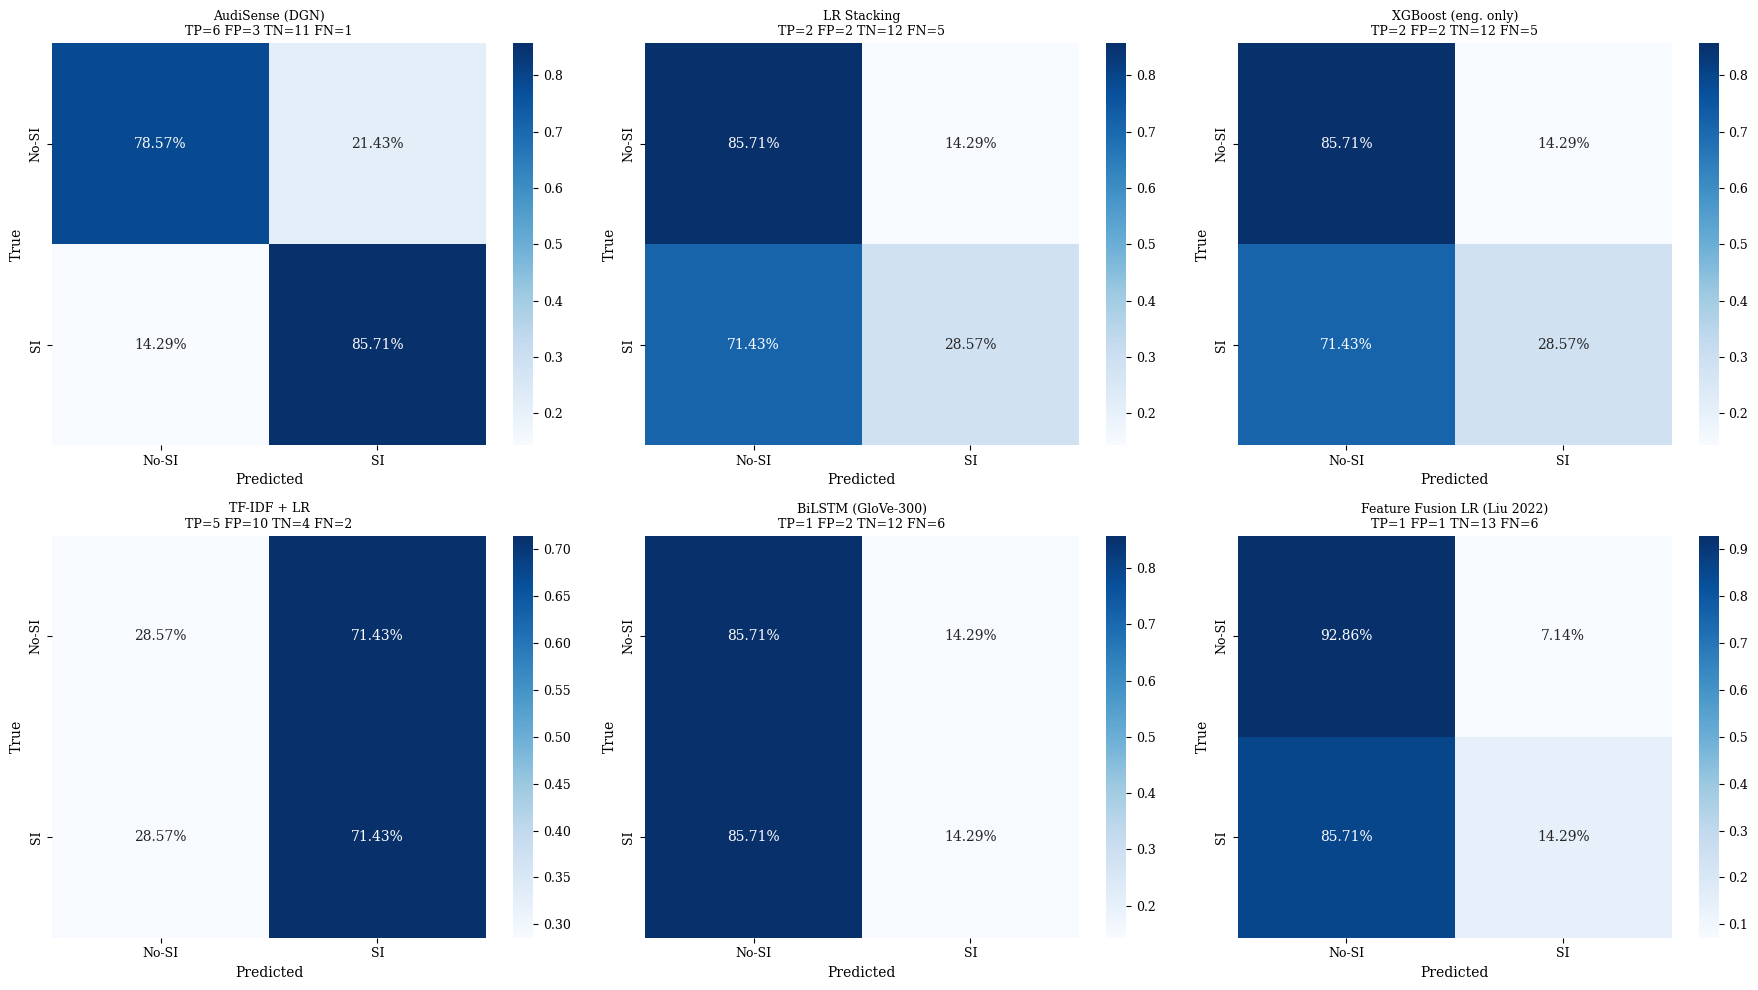

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

systems_cm = [
    ("AudiSense (DGN)",              gating_test_probs,    gating_threshold),
    ("LR Stacking",                  lr_test_probs,        lr_threshold),
    ("XGBoost (eng. only)",           xgb_test_probs,       xgb_threshold),
    ("TF-IDF + LR",                  tfidf_lr_test_probs,  tfidf_lr_threshold),
    ("BiLSTM (GloVe-300)",           bilstm_test_probs,    bilstm_threshold),
    ("Feature Fusion LR (Liu 2022)", fusion_test_probs,    fusion_threshold),
]

for ax, (name, probs, thr) in zip(axes, systems_cm):
    y_pred = (probs >= thr).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    cm_n   = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    TP = cm[1,1]; FP = cm[0,1]; TN = cm[0,0]; FN = cm[1,0]
    sns.heatmap(cm_n, annot=True, fmt=".2%", cmap="Blues", ax=ax,
                xticklabels=["No-SI","SI"],
                yticklabels=["No-SI","SI"])
    ax.set_title(f"{name}\nTP={TP} FP={FP} TN={TN} FN={FN}", fontsize=9)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("AudiSense_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Roc and precision curves

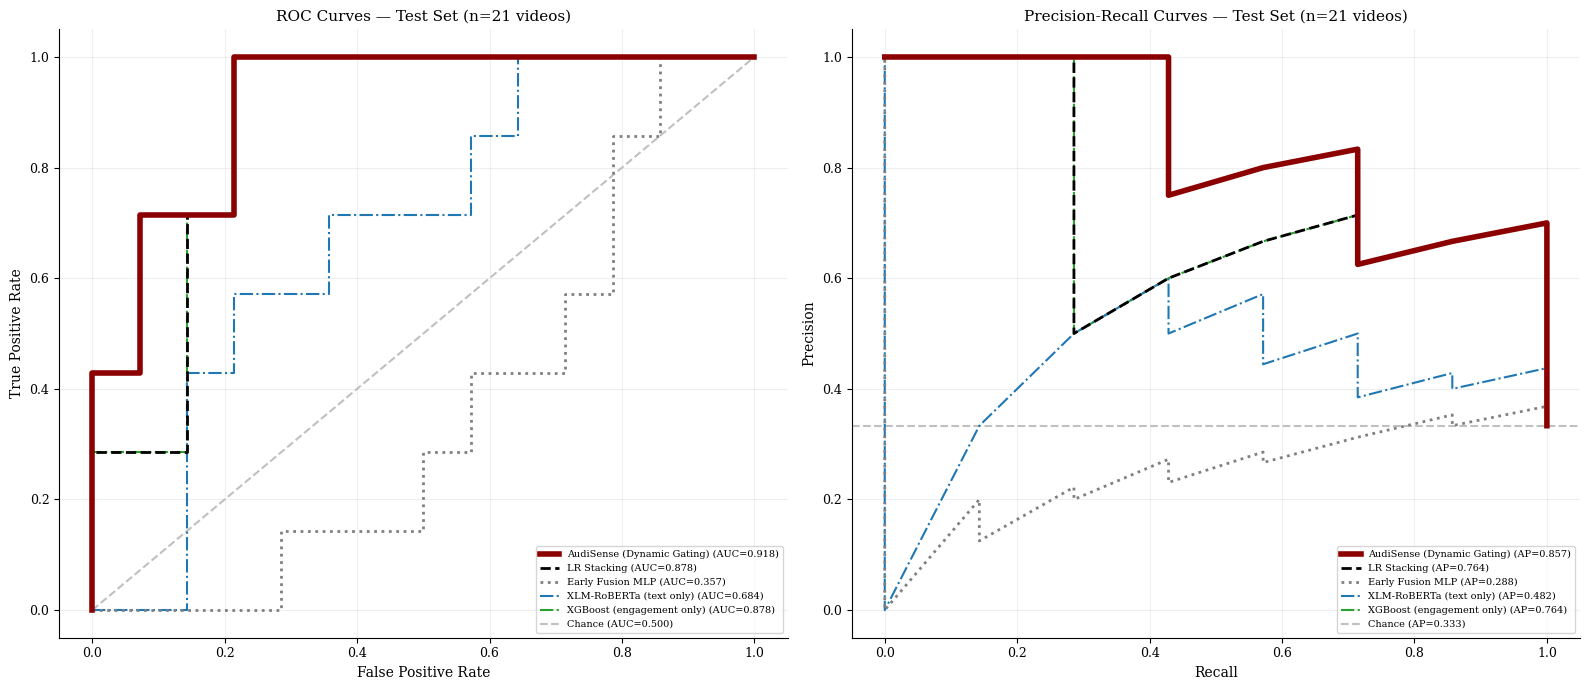

Curves saved to AudiSense_ROC_PR_curves.png


In [ ]:
styles = {
    "AudiSense (Dynamic Gating)":   dict(color="#8B0000", lw=4,   ls="-",   zorder=10),
    "LR Stacking":                  dict(color="black",   lw=2,   ls="--",  zorder=9),
    "Early Fusion MLP":             dict(color="gray",    lw=2,   ls=":",   zorder=8),
    "XLM-RoBERTa (text only)":      dict(color="#1f77b4", lw=1.5, ls="-.", zorder=7),
    "XGBoost (engagement only)":    dict(color="#2ca02c", lw=1.5, ls="-.", zorder=6),



}

probs_map = {
    "AudiSense (Dynamic Gating)":   gating_test_probs,
    "LR Stacking":                  lr_test_probs,
    "Early Fusion MLP":             ef_test_probs,
    "XLM-RoBERTa (text only)":      xlmr_test_probs,
    "XGBoost (engagement only)":    xgb_test_probs,
    }

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ROC
ax = axes[0]
for name, probs in probs_map.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_val:.3f})", **styles[name])
ax.plot([0,1],[0,1], color="silver", lw=1.5, ls="--", label="Chance (AUC=0.500)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves — Test Set (n={len(y_test)} videos)")
ax.legend(loc="lower right", fontsize=7, frameon=True)
ax.grid(True, alpha=0.2)



# PR
ax = axes[1]
for name, probs in probs_map.items():
    prec_v, rec_v, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(rec_v, prec_v, label=f"{name} (AP={ap:.3f})", **styles[name])
ax.axhline(y_test.mean(), color="silver", lw=1.5, ls="--",
           label=f"Chance (AP={y_test.mean():.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curves — Test Set (n={len(y_test)} videos)")
ax.legend(loc="lower right", fontsize=7, frameon=True)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("AudiSense_ROC_PR_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Curves saved to AudiSense_ROC_PR_curves.png")


## XGBoost feature importance

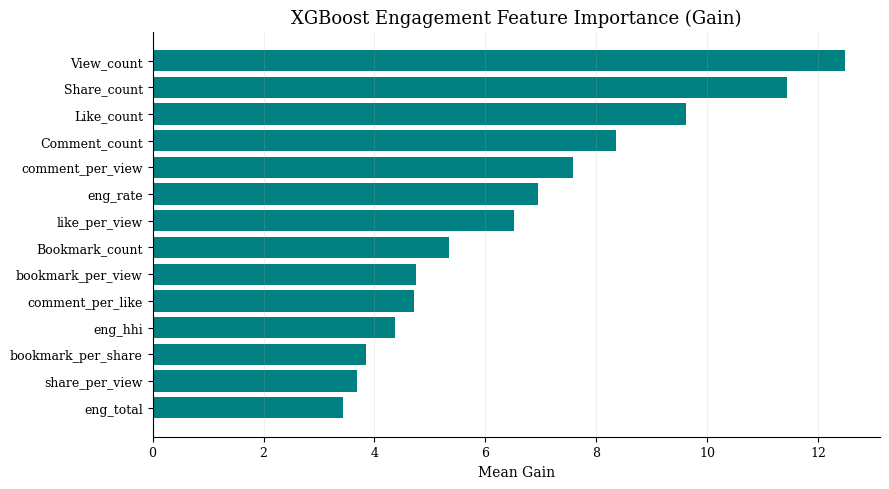

In [ ]:
importance = xgb_final.get_booster().get_score(importance_type="gain")
imp_mapped  = {}
for k, v in importance.items():
    idx = int(k[1:])
    if idx < len(FEAT_COLS):
        imp_mapped[FEAT_COLS[idx]] = v

df_imp = (pd.DataFrame(list(imp_mapped.items()), columns=["Feature","Gain"])
          .sort_values("Gain", ascending=True))

plt.figure(figsize=(9, 5))
plt.barh(df_imp["Feature"], df_imp["Gain"], color="teal")
plt.title("XGBoost Engagement Feature Importance (Gain)", fontsize=13)
plt.xlabel("Mean Gain")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig("AudiSense_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## Gating alpha distribution

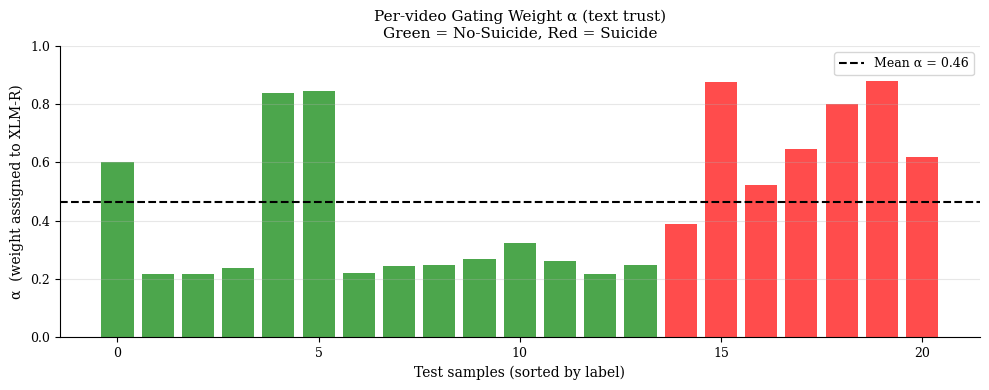

Mean α (all)        : 0.463
Mean α (positive)   : 0.676
Mean α (negative)   : 0.357


In [ ]:
# Alpha = 1 → model trusts text; Alpha ≈ 0 → model trusts engagement.
X_test_t   = torch.tensor(X_meta_test, dtype=torch.float32)
test_alphas = final_gating.gate(X_test_t).squeeze().detach().numpy()

plt.figure(figsize=(10, 4))
indices = np.argsort(y_test)
colors  = ["green" if y == 0 else "red" for y in y_test[indices]]
plt.bar(range(len(test_alphas)), test_alphas[indices], color=colors, alpha=0.7)
plt.axhline(np.mean(test_alphas), color="black", ls="--",
            label=f"Mean α = {np.mean(test_alphas):.2f}")
plt.title("Per-video Gating Weight α (text trust)\nGreen = No-Suicide, Red = Suicide")
plt.xlabel("Test samples (sorted by label)")
plt.ylabel("α  (weight assigned to XLM-R)")
plt.ylim(0, 1)
plt.legend(); plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("AudiSense_alpha_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean α (all)        : {test_alphas.mean():.3f}")
print(f"Mean α (positive)   : {test_alphas[y_test==1].mean():.3f}")
print(f"Mean α (negative)   : {test_alphas[y_test==0].mean():.3f}")


## Engagement Feature Correlation Matrix

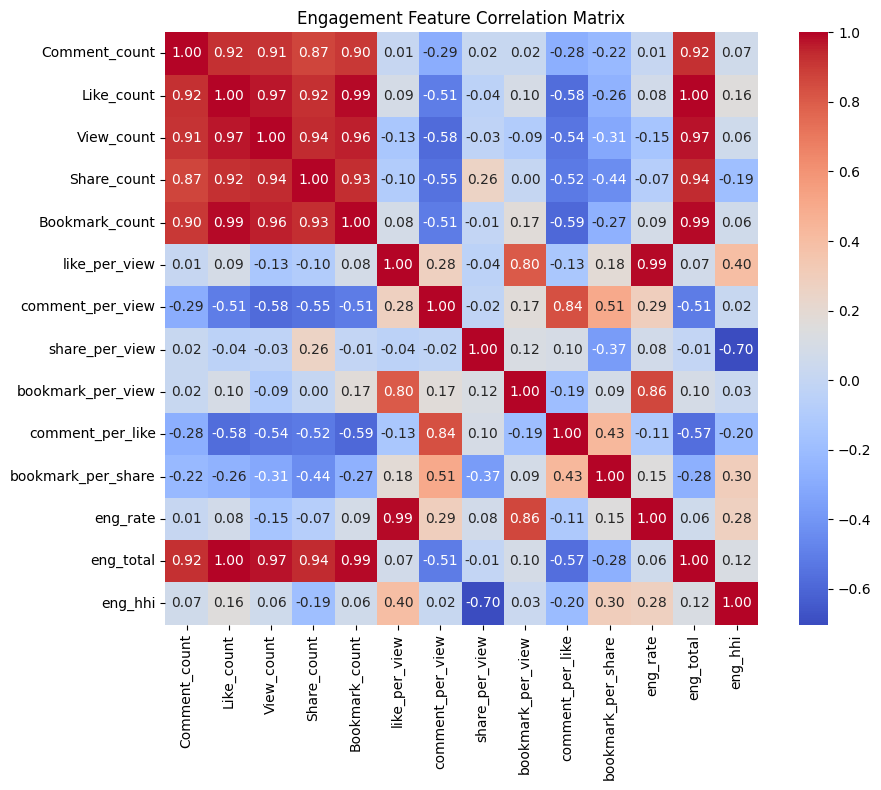

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = train_feat[FEAT_COLS].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Engagement Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(
    "engagement_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Log transform distributions

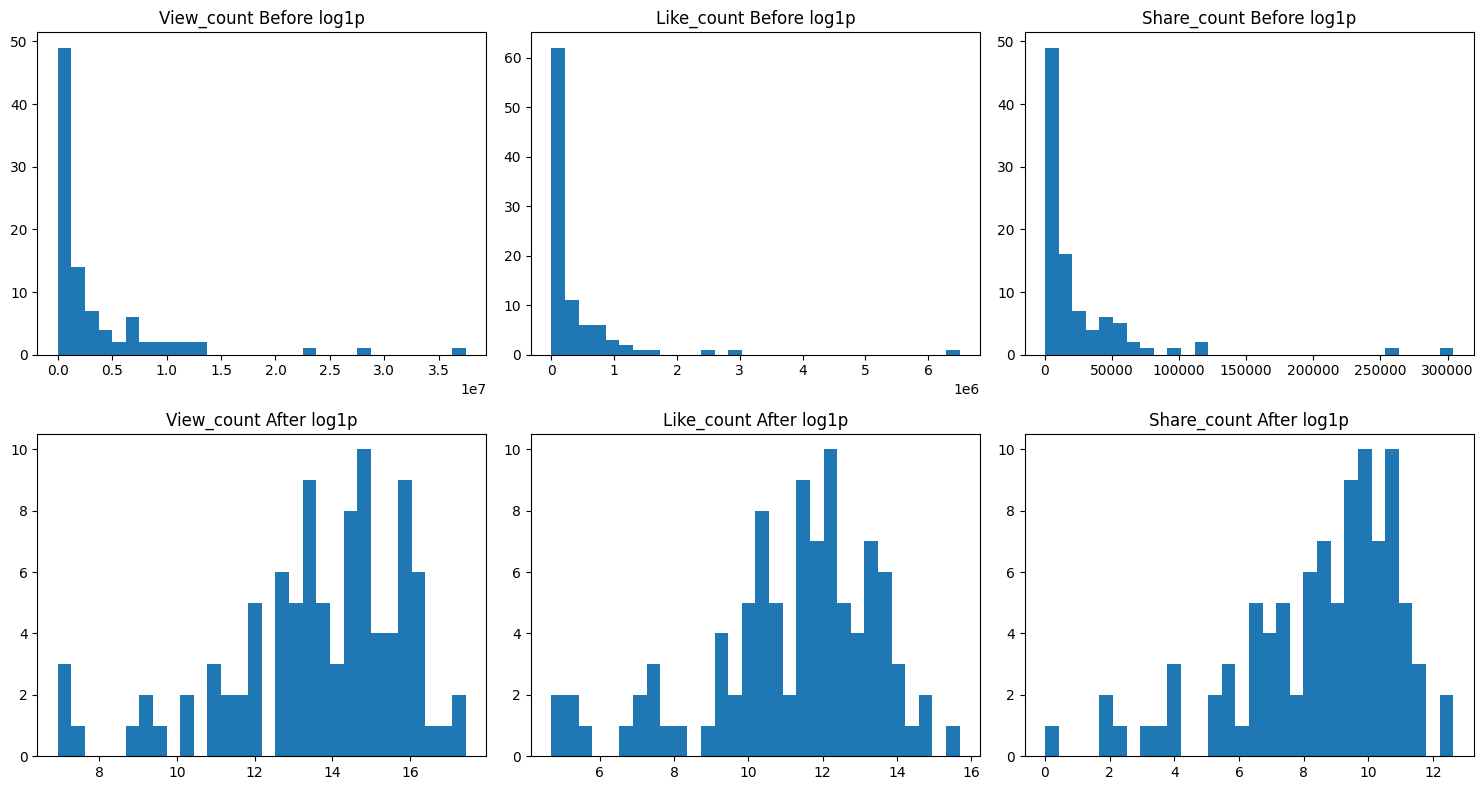

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = [
    "View_count",
    "Like_count",
    "Share_count"
]

for i, col in enumerate(features):

    # BEFORE LOG
    axes[0, i].hist(train_df[col], bins=30)
    axes[0, i].set_title(f"{col} Before log1p")

    # AFTER LOG
    axes[1, i].hist(np.log1p(train_df[col]), bins=30)
    axes[1, i].set_title(f"{col} After log1p")

plt.tight_layout()

plt.savefig(
    "log_transform_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Dataset label distribution

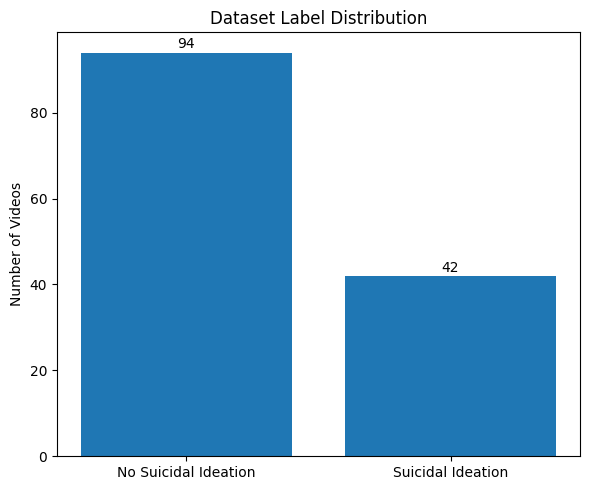

In [ ]:
import matplotlib.pyplot as plt

counts = df.groupby("video_id")["True_Label"].first().value_counts()

labels = [
    "No Suicidal Ideation",
    "Suicidal Ideation"
]

plt.figure(figsize=(6,5))

plt.bar(labels, counts.values)

plt.ylabel("Number of Videos")
plt.title("Dataset Label Distribution")

for i, v in enumerate(counts.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.tight_layout()

plt.savefig(
    "dataset_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Top 20 Hashtags in suicidal Ideation TikTok videos

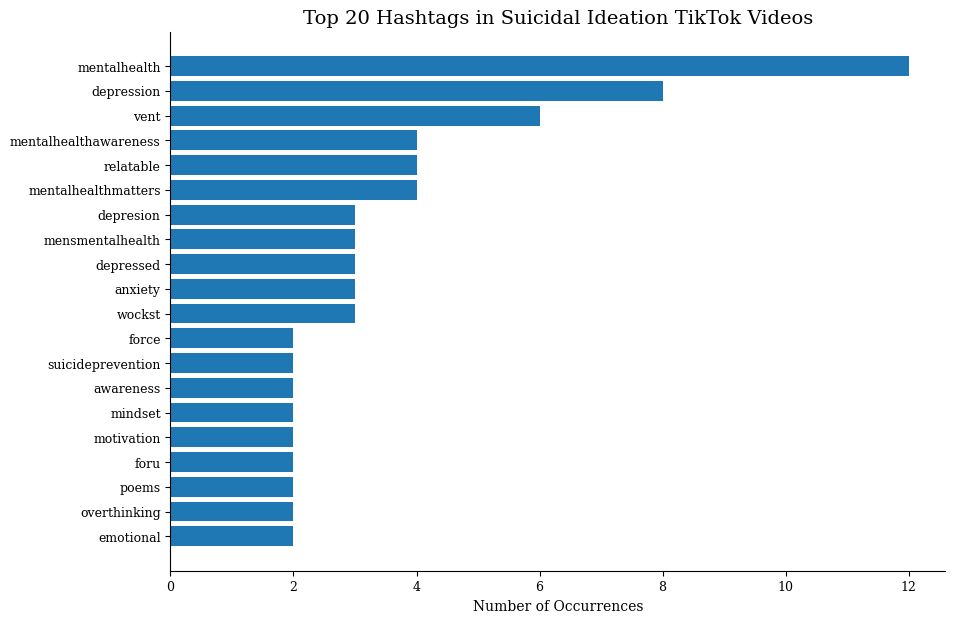

In [ ]:
import matplotlib.pyplot as plt
import re
from collections import Counter

df_pos = df_v[df_v["True_Label"] == 1]

# EXTRACT HASHTAGS
all_tags = []
for h in df_pos["video_hashtags"].fillna("").astype(str):
    tags = re.findall(r"#\w+", h.lower())
    for t in tags:
        # keep only letters/numbers
        t = re.sub(r"[^a-zA-Z0-9]", "", t)
        # ignore very short garbage
        if len(t) < 4:
            continue
        all_tags.append(t)


# REMOVE GENERIC HASHTAGS
stop_tags = {
    "viral", "foryou", "tiktok", "fy",
    "trending", "explore", "xyzbca",
    "foryoupage", "capcut",
    "pourtoi", "parati"
}
filtered = [
    t for t in all_tags
    if (
        t not in stop_tags
        and not t.startswith("fyp")
    )
]
# TOP 20
counts = Counter(filtered).most_common(20)
tags   = [t for t, _ in counts][::-1]
values = [c for _, c in counts][::-1]

#PLOT
plt.figure(figsize=(10, 7))
bars = plt.barh(tags, values)
plt.xlabel("Number of Occurrences")
plt.title(
    "Top 20 Hashtags in Suicidal Ideation TikTok Videos",
    fontsize=14
)
#save
plt.savefig(
    "fig_top_hashtags_positive.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Répartition stratifiée du jeu de données

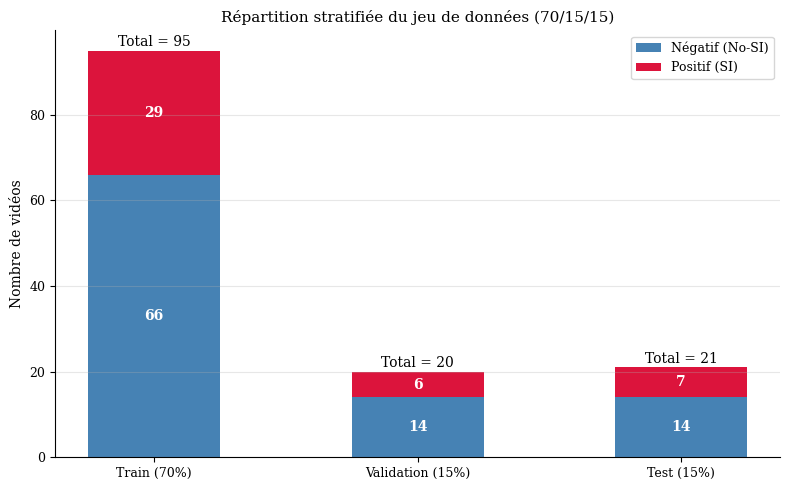

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#les classes dans chaque split
splits = ["Train (70%)", "Validation (15%)", "Test (15%)"]
neg = [len(y_train) - sum(y_train), len(y_val) - sum(y_val), len(y_test) - sum(y_test)]
pos = [sum(y_train), sum(y_val), sum(y_test)]

x = np.arange(len(splits))
width = 0.5

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x, neg, width, label="Négatif (No-SI)", color="steelblue")
b2 = ax.bar(x, pos, width, bottom=neg, label="Positif (SI)", color="crimson")

#Annoter
for i, (n, p) in enumerate(zip(neg, pos)):
    ax.text(i, n/2, str(n), ha="center", va="center", color="white", fontweight="bold")
    ax.text(i, n + p/2, str(p), ha="center", va="center", color="white", fontweight="bold")
    ax.text(i, n + p + 1, f"Total = {n+p}", ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel("Nombre de vidéos")
ax.set_title("Répartition stratifiée du jeu de données (70/15/15)")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_split_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

## Comparaison des performances par modèle

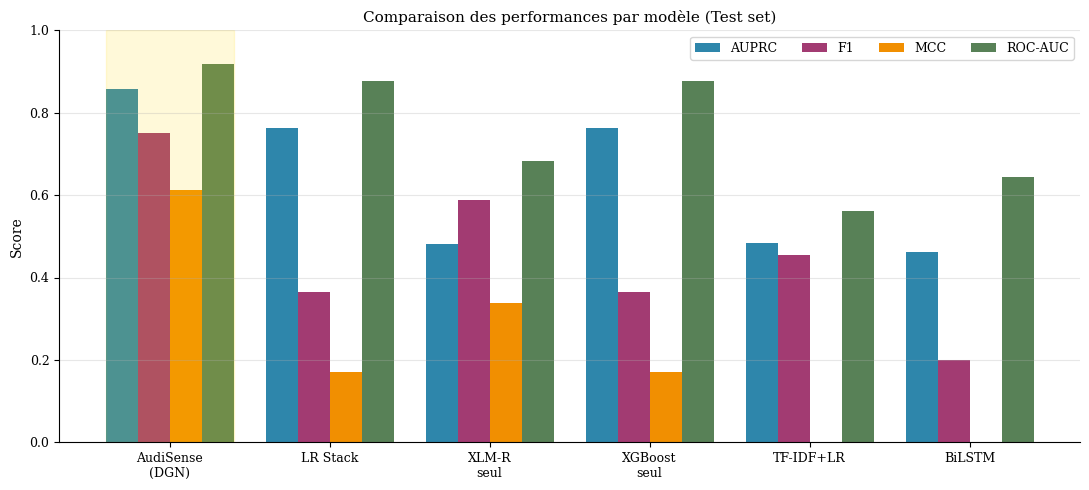

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

wanted_models = [
    "AudiSense (Dynamic Gating)",
    "XLM-RoBERTa (text only)",
    "XGBoost (engagement only)",
    "TF-IDF + LR",
    "BiLSTM (GloVe-300)",
    "LR Stacking"
]

filtered_results = [
    r for r in all_results
    if r["name"] in wanted_models
]

#models name

rename_map = {
    "AudiSense (Dynamic Gating)" : "AudiSense\n(DGN)",
    "XLM-RoBERTa (text only)"    : "XLM-R\nseul",
    "XGBoost (engagement only)"  : "XGBoost\nseul",
    "TF-IDF + LR"                : "TF-IDF+LR",
    "BiLSTM (GloVe-300)"         : "BiLSTM",
    "LR Stacking"                : "LR Stack"
}

modeles = [
    rename_map[r["name"]]
    for r in filtered_results
]


#metrics
auprc   = [r["auprc"]   for r in filtered_results]
f1      = [r["f1"]      for r in filtered_results]
mcc     = [r["mcc"]     for r in filtered_results]
roc_auc = [r["roc_auc"] for r in filtered_results]

#figure
x = np.arange(len(modeles))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 1.5*width, auprc,   width,
       label="AUPRC",   color="#2E86AB")
ax.bar(x - 0.5*width, f1,      width,
       label="F1",      color="#A23B72")
ax.bar(x + 0.5*width, mcc,     width,
       label="MCC",     color="#F18F01")
ax.bar(x + 1.5*width, roc_auc, width,
       label="ROC-AUC", color="#588157")


#format
ax.set_xticks(x)
ax.set_xticklabels(modeles)
ax.set_ylabel("Score")
ax.set_title(
    "Comparaison des performances par modèle (Test set)"
)

ax.legend(loc="upper right", ncol=4)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1)

# Highlight
ax.axvspan(
    -0.4,
    0.4,
    alpha=0.15,
    color="gold",
    label="_nolegend_"
)

plt.tight_layout()


#save
plt.savefig(
    "fig_comparaison_metriques.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()